# `asycaus` — Asymmetric Granger-Causality Suite

### Full demo on real-world data: crude-oil shocks → S&P 500

**Author:** Dr Merwan Roudane &nbsp;·&nbsp; <merwanroudane920@gmail.com>

**Links:**
- GitHub: <https://github.com/merwanroudane/asycaus>
- PyPI: <https://pypi.org/project/asycaus/>
- Stata twin (SSC): `ssc install asycaus`

---

This notebook runs every test in the `asycaus` library on a real dataset and
saves all tables and figures into `docs/tables/` and `docs/figures/` so they
can be reproduced and embedded in the GitHub Pages site.

The empirical setup follows **Hatemi-J (2012)**: do positive vs negative shocks
in crude-oil prices have *different* causal effects on the world's largest
stock market?


## 1. Setup

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import asycaus
print('asycaus version:', asycaus.__version__)
print('Author         :', asycaus.__author__, '<' + asycaus.__email__ + '>')
print('GitHub         :', asycaus.__url__)

# Where to drop tables and figures so docs/ embeds them automatically
ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == 'examples' else os.getcwd()
FIG_DIR = os.path.join(ROOT, 'docs', 'figures')
TBL_DIR = os.path.join(ROOT, 'docs', 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)
print('FIG_DIR:', FIG_DIR)
print('TBL_DIR:', TBL_DIR)


asycaus version: 1.0.0
Author         : Dr Merwan Roudane <merwanroudane920@gmail.com>
GitHub         : https://github.com/merwanroudane/asycaus
FIG_DIR: C:\Users\HP\Documents\xtpmg\asycaus\asycaus_py\docs\figures
TBL_DIR: C:\Users\HP\Documents\xtpmg\asycaus\asycaus_py\docs\tables


## 2. Real data — WTI crude oil and S&P 500

We download daily closing prices from Yahoo Finance (2015–2024) and convert to
monthly log levels, the standard frequency for causality studies in finance.


In [2]:
raw = yf.download(['CL=F', '^GSPC'], start='2015-01-01', end='2024-12-31',
                  progress=False, auto_adjust=True)['Close']
raw = raw.rename(columns={'CL=F': 'oil', '^GSPC': 'sp500'}).dropna()

# Monthly frequency, end-of-month closes -> log levels
monthly = raw.resample('M').last().apply(np.log).dropna()
monthly.columns = ['ln_oil', 'ln_sp500']
print(monthly.shape, 'monthly observations')
monthly.head()


(120, 2) monthly observations


,ln_oil,ln_sp500
Date,,
2015-01-31,3.876189,7.598394
2015-02-28,3.907211,7.651833
2015-03-31,3.862833,7.634284
2015-04-30,4.088159,7.642769
2015-05-31,4.099332,7.653205


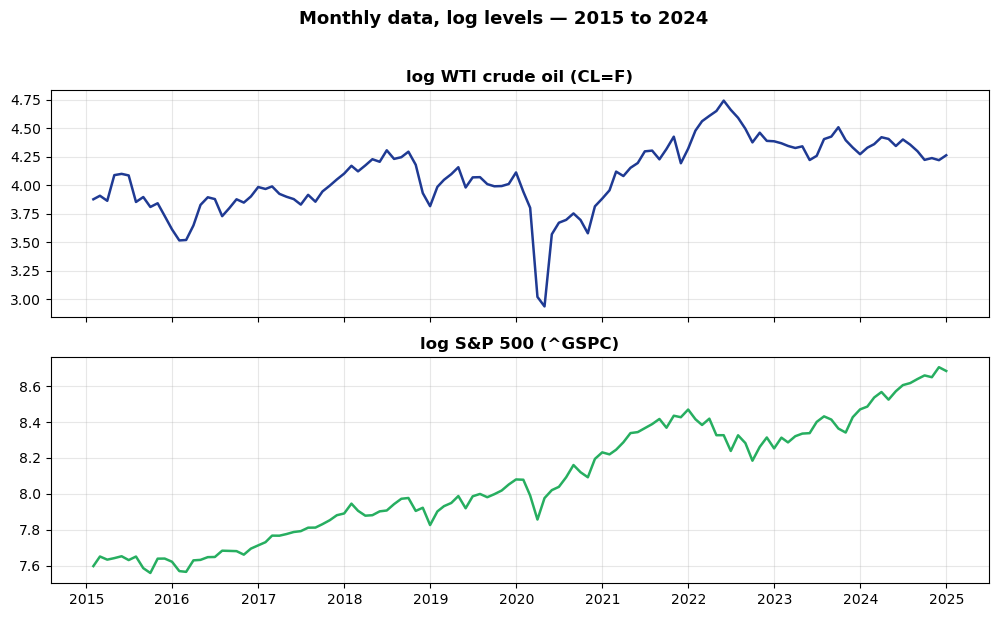

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(monthly.index, monthly['ln_oil'], color='#1f3a93', lw=1.8)
axes[0].set_title('log WTI crude oil (CL=F)', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[1].plot(monthly.index, monthly['ln_sp500'], color='#27ae60', lw=1.8)
axes[1].set_title('log S&P 500 (^GSPC)', fontweight='bold')
axes[1].grid(alpha=0.3)
plt.suptitle('Monthly data, log levels — 2015 to 2024',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '00_data.png'), bbox_inches='tight', dpi=170)
plt.show()


## 3. Cumulative positive / negative shocks (Granger-Yoon 2002)

Each variable is split into the cumulative sum of its positive innovations and
the cumulative sum of its negative innovations. This is the heart of the
asymmetric causality framework: instead of testing whether `oil` causes
`sp500`, we test whether **positive oil shocks** cause **positive S&P shocks**
(or any combination).


In [4]:
y = monthly['ln_sp500'].to_numpy()   # dependent variable
x = monthly['ln_oil'].to_numpy()     # candidate cause
Y = np.column_stack([y, x])

C_pos = asycaus.pos_neg_components(Y, positive=True)
C_neg = asycaus.pos_neg_components(Y, positive=False)

comp = pd.DataFrame(
    np.hstack([C_pos, C_neg]),
    columns=['cum_pos_sp500', 'cum_pos_oil', 'cum_neg_sp500', 'cum_neg_oil'],
    index=monthly.index[1:],
)
comp.head()


,cum_pos_sp500,cum_pos_oil,cum_neg_sp500,cum_neg_oil
Date,,,,
2015-02-28,0.053439,0.031023,0.000000,0.000000
2015-03-31,0.053439,0.031023,-0.017549,-0.044379
2015-04-30,0.061924,0.256349,-0.017549,-0.044379
2015-05-31,0.072360,0.267522,-0.017549,-0.044379
2015-06-30,0.072360,0.267522,-0.038785,-0.058239


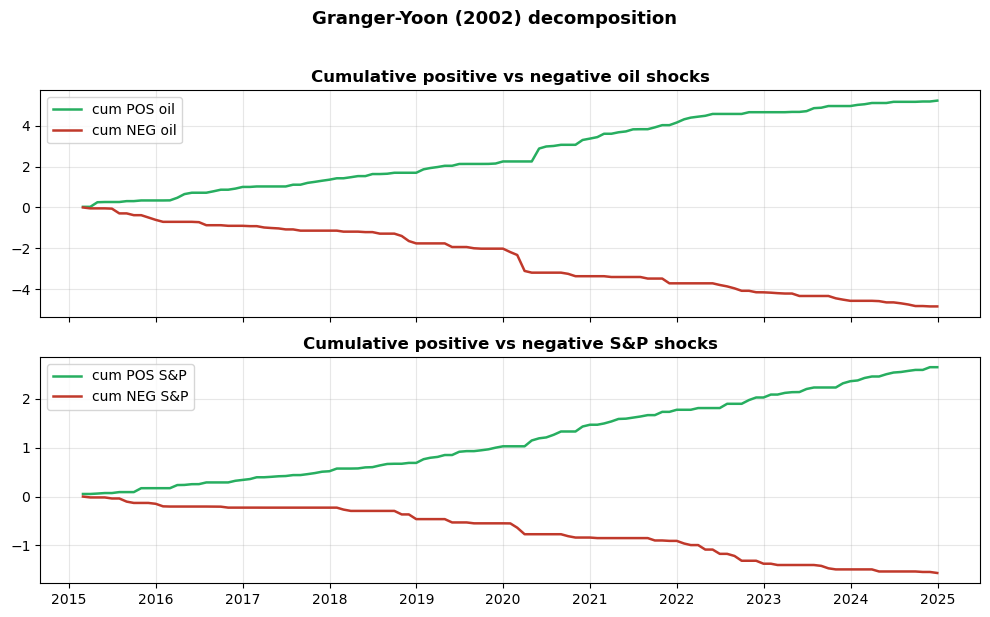

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(comp.index, comp['cum_pos_oil'],   color='#27ae60', label='cum POS oil',   lw=1.8)
axes[0].plot(comp.index, comp['cum_neg_oil'],   color='#c0392b', label='cum NEG oil',   lw=1.8)
axes[0].set_title('Cumulative positive vs negative oil shocks', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(comp.index, comp['cum_pos_sp500'], color='#27ae60', label='cum POS S&P',   lw=1.8)
axes[1].plot(comp.index, comp['cum_neg_sp500'], color='#c0392b', label='cum NEG S&P',   lw=1.8)
axes[1].set_title('Cumulative positive vs negative S&P shocks', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Granger-Yoon (2002) decomposition', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_components.png'), bbox_inches='tight', dpi=170)
plt.show()


## 4. Static asymmetric causality — Hatemi-J (2012)

Modified Wald in a VAR(p+1) on the cumulative components, with bootstrap
critical values that use the **leverage-adjustment** of Hacker & Hatemi-J
(2006, 2012). The bootstrap is robust to non-normality and ARCH — both common
in oil and equity returns.


────────────────────────────────── Asymmetric Causality Test -- Hatemi-J (2012) ───────────────────────────────────

H0: x does not Granger-cause y

Lag selection: HJC    Augmentation lags: 1    Bootstrap reps: 500    Sample: 119

           Asymmetric Causality Test  --  Hatemi-J (2012)            
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━┓
┃ Shock    ┃   Wald ┃ Lag ┃  Asy p ┃ CV 10% ┃  CV 5% ┃  CV 1% ┃ Sig ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━┩
│ Positive │ 0.0482 │   1 │ 0.8261 │ 0.3594 │ 0.5163 │ 0.9617 │     │
│ Negative │ 0.2710 │   1 │ 0.6027 │ 0.3619 │ 0.4991 │ 0.9467 │     │
└──────────┴────────┴─────┴────────┴────────┴────────┴────────┴─────┘

Significance: * 10%  ** 5%  *** 1%  (leverage-adjusted bootstrap CVs)

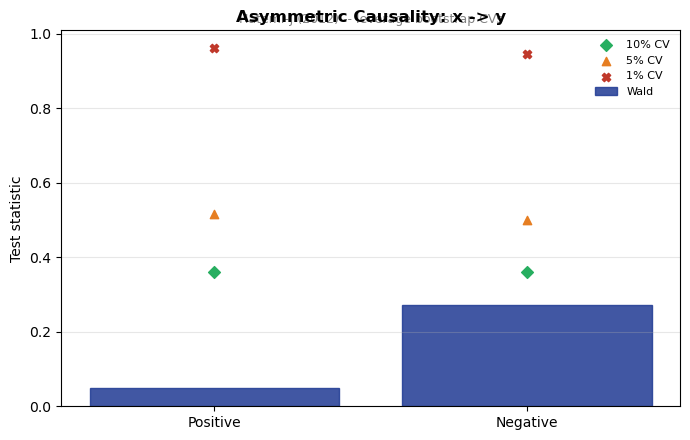

In [6]:
static = asycaus.static(y, x, shock='both', max_lag=6,
                        boot=500, seed=12345, plot=False)
static.table.to_csv(os.path.join(TBL_DIR, '01_static.csv'))
fig = static.plot(save=os.path.join(FIG_DIR, '02_static.png'))


## 5. Dynamic asymmetric causality — Hatemi-J (2021)

The static test gives a single Wald statistic for the whole sample, but the
oil-stock relationship is known to be unstable (Gulf War, 2014–16 oil glut,
COVID crash, 2022 invasion of Ukraine). We re-estimate the test on a rolling
window of size

$$S = \left\lceil T\bigl(0.01 + 1.8/\sqrt T\bigr)\right\rceil$$

(Phillips, Shi & Yu 2015) for *positive* shocks, then for *negative* shocks.
The resulting Wald time-series shows precisely **when** asymmetric causation
turns on and off.


───────────────────────────────── Dynamic Asymmetric Causality -- Hatemi-J (2021) ─────────────────────────────────

H0: x does not Granger-cause y  (pos shocks)

Mode: Rolling window    Window: 21  (PSY min=21)    Lag IC: HJC    Boot: 120

        Dynamic Asymmetric Causality -- Hatemi-J (2021)         
┏━━━━━━━━┳━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ SS End ┃ Lag ┃    Wald ┃ CV 10% ┃   CV 5% ┃   CV 1% ┃ W/CV5% ┃
┡━━━━━━━━╇━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│     21 │   1 │  0.0157 │ 0.3887 │  0.5042 │  1.0244 │ 0.0312 │
│     31 │   3 │ 12.0298 │ 9.1808 │ 18.0657 │ 30.9636 │ 0.6659 │
│     41 │   1 │  0.2129 │ 0.3674 │  0.5388 │  0.8526 │ 0.3950 │
│     51 │   1 │  0.1728 │ 0.7829 │  1.3274 │  2.1312 │ 0.1302 │
│     61 │   1 │  0.0001 │ 0.6050 │  0.9522 │  1.9664 │ 0.0001 │
│     71 │   1 │  0.0060 │ 0.3144 │  0.4810 │  3.4088 │ 0.0125 │
│     81 │   3 │  0.4177 │ 3.2435 │  5.2694 │ 10.1631 │ 0.0793 │
│     91 │   2 │  4.1522 │ 4.2422 │  7.2437 │ 12.5349 │ 0.5732 │
│    101 │   2 │  0.1800 │ 6.0706 │ 10.8703 │ 20.2916 │ 0.0166 │
│    111 │   1 │  0.1301 │ 1.5982 │  2.5171 │  3.4851 │ 0.0517 │
│    119 │   3 │  0.6511 │ 7.2811 │  9.0812 │ 18.6690 │ 0.0717 │
└────────┴─────┴─────────┴────────┴─────────┴─────────┴────────┘

Subsamples rejecting H0: 0 at 1%,  1 at 5%,  6 at 10%   (of 99 windows)

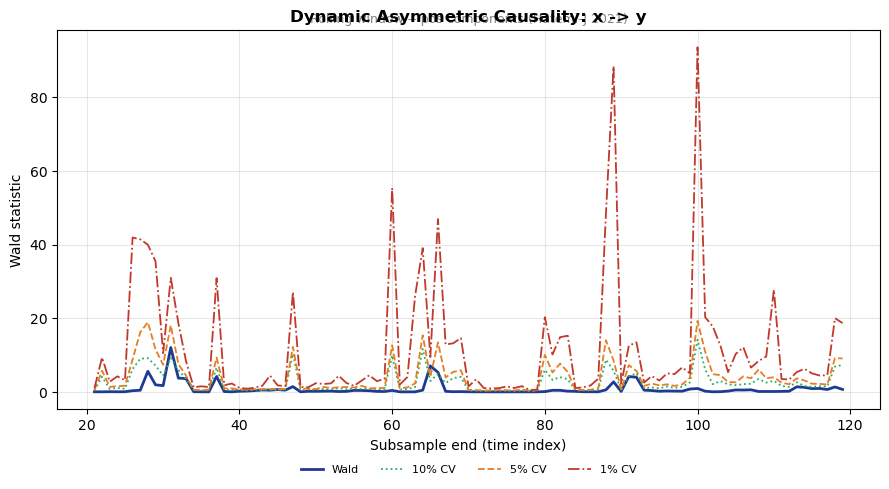

In [7]:
dyn_pos = asycaus.dynamic(y, x, shock='pos', mode='rolling',
                          max_lag=3, boot=120, seed=12345,
                          plot=False, progress=False)
dyn_pos.table.to_csv(os.path.join(TBL_DIR, '02_dynamic_pos.csv'))
fig = dyn_pos.plot(save=os.path.join(FIG_DIR, '03_dynamic_pos.png'))


───────────────────────────────── Dynamic Asymmetric Causality -- Hatemi-J (2021) ─────────────────────────────────

H0: x does not Granger-cause y  (neg shocks)

Mode: Rolling window    Window: 21  (PSY min=21)    Lag IC: HJC    Boot: 120

        Dynamic Asymmetric Causality -- Hatemi-J (2021)         
┏━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ SS End ┃ Lag ┃   Wald ┃  CV 10% ┃   CV 5% ┃   CV 1% ┃ W/CV5% ┃
┡━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│     21 │   1 │ 0.6923 │  0.3222 │  0.5034 │  0.8023 │ 1.3753 │
│     31 │   2 │ 0.1215 │  3.3492 │  5.6978 │ 15.1941 │ 0.0213 │
│     41 │   1 │ 0.0000 │  0.5383 │  1.2310 │  3.0147 │ 0.0000 │
│     51 │   1 │ 1.7133 │  0.5635 │  0.7788 │  1.6070 │ 2.2001 │
│     61 │   1 │ 1.4152 │  0.5019 │  0.7141 │  2.0098 │ 1.9819 │
│     71 │   3 │ 6.7229 │ 16.6613 │ 34.8853 │ 81.5259 │ 0.1927 │
│     81 │   2 │ 1.2522 │  3.3061 │  4.8712 │ 10.8622 │ 0.2571 │
│     91 │   2 │ 3.0784 │  6.5420 │ 10.4382 │ 20.7934 │ 0.2949 │
│    101 │   2 │ 2.1425 │  3.6202 │  5.3668 │ 17.3089 │ 0.3992 │
│    111 │   2 │ 1.8291 │  3.1406 │  5.0400 │  7.1745 │ 0.3629 │
│    119 │   2 │ 0.4468 │  5.5704 │  6.8184 │ 13.7273 │ 0.0655 │
└────────┴─────┴────────┴─────────┴─────────┴─────────┴────────┘

Subsamples rejecting H0: 7 at 1%,  20 at 5%,  24 at 10%   (of 99 windows)

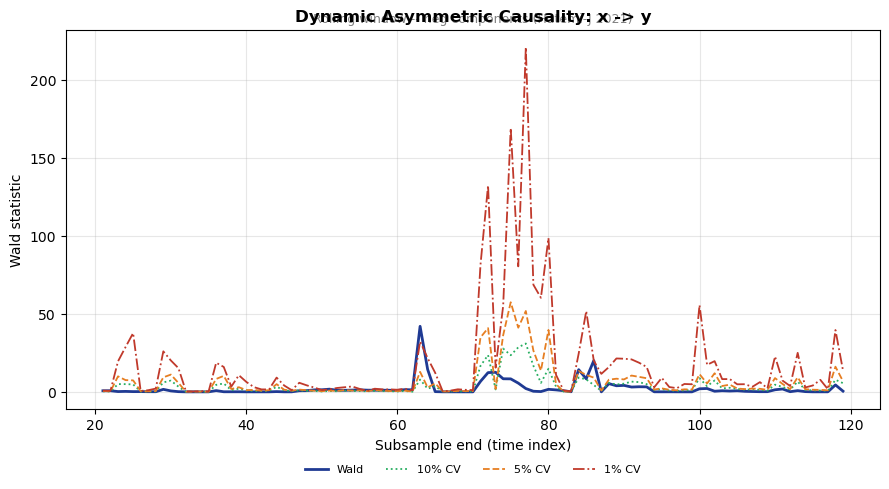

In [8]:
dyn_neg = asycaus.dynamic(y, x, shock='neg', mode='rolling',
                          max_lag=3, boot=120, seed=12345,
                          plot=False, progress=False)
dyn_neg.table.to_csv(os.path.join(TBL_DIR, '03_dynamic_neg.csv'))
fig = dyn_neg.plot(save=os.path.join(FIG_DIR, '04_dynamic_neg.png'))


## 6. Fourier-augmented asymmetric TY — Nazlioglu et al. (2016) / Pata (2020)

Smooth structural breaks of unknown number, timing and form are absorbed by
sine/cosine terms inserted into the VAR. The frequency `k*` is chosen
automatically over `k ∈ {1,…,k_max}`.


Fourier Asymmetric TY Causality (Nazlioglu et al. 2016)
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━┳━━━━━━━━┳━━━━━┳━━━━━┓
┃ Shock    ┃     Wald ┃ Lag ┃ k* ┃  Asy p ┃ Obs ┃ Sig ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━╇━━━━━━━━╇━━━━━╇━━━━━┩
│ Positive │ 101.5157 │   1 │  1 │ 0.0000 │ 119 │ *** │
│ Negative │ 332.3207 │   1 │  3 │ 0.0000 │ 119 │ *** │
└──────────┴──────────┴─────┴────┴────────┴─────┴─────┘

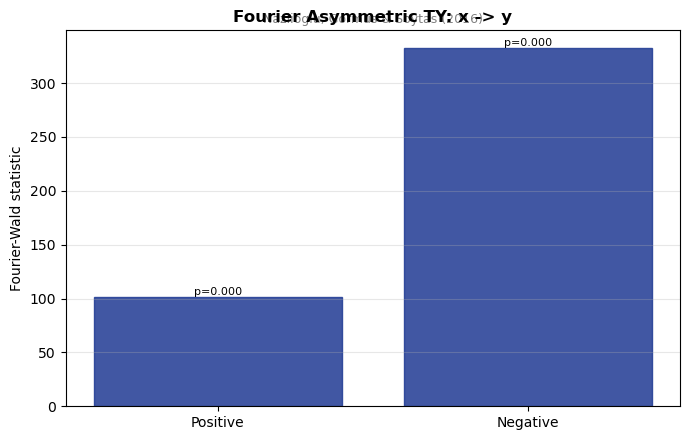

In [9]:
fr = asycaus.fourier(y, x, shock='both', kmax=4, form='single',
                     max_lag=6, plot=False)
fr.table.to_csv(os.path.join(TBL_DIR, '04_fourier.csv'))
fig = fr.plot(save=os.path.join(FIG_DIR, '05_fourier.png'))


## 7. Frequency-domain asymmetric causality — Bahmani-Oskooee, Chang & Ranjbar (2016)

Breitung-Candelon (2006) spectral causality applied separately to the cumulative
positive and negative components. For each angular frequency $\omega \in (0, \pi]$
we report a $\chi^2(2)$ Wald statistic. The plot shows the *Wald-vs-frequency*
curve with 1%, 5%, 10% critical lines — the canonical Bahmani-Oskooee
presentation.


           Asymmetric Frequency-Domain Causality (BCRanjbar 2016)           
┏━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Shock    ┃ Lag ┃ n_reject_1% ┃ n_reject_5% ┃ n_reject_10% ┃ % reject @5% ┃
┡━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Positive │   1 │           0 │           0 │            0 │        0.00% │
│ Negative │   1 │           0 │           0 │            0 │        0.00% │
└──────────┴─────┴─────────────┴─────────────┴──────────────┴──────────────┘

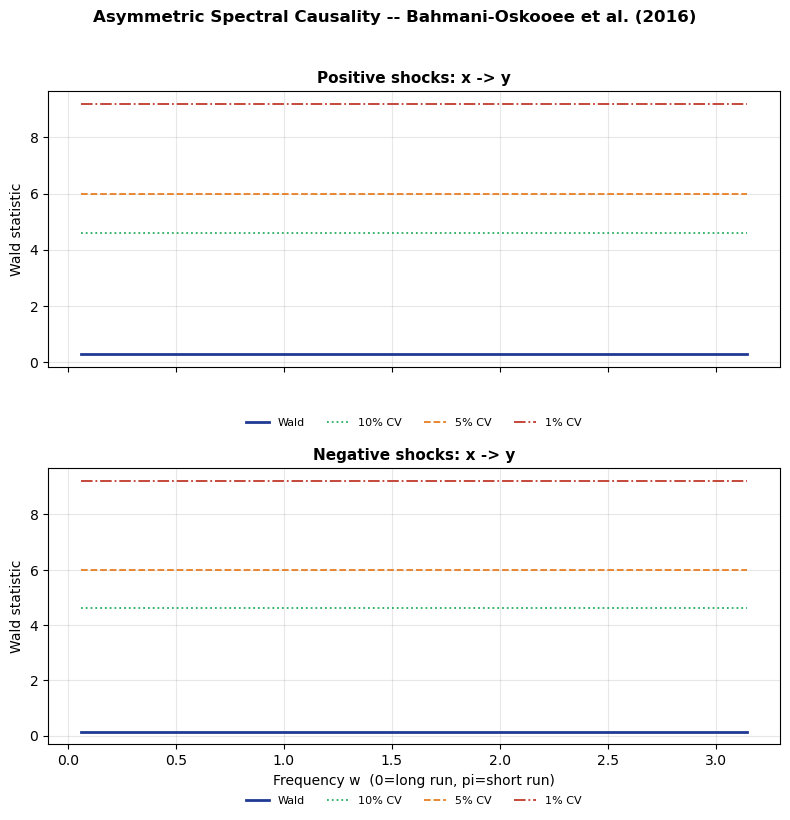

In [10]:
sp = asycaus.spectral(y, x, shock='both', nfreq=50, max_lag=6, plot=False)
sp.summary.to_csv(os.path.join(TBL_DIR, '05_spectral_summary.csv'))
sp.table.to_csv(os.path.join(TBL_DIR, '05_spectral_full.csv'), index=False)
fig = sp.plot(save=os.path.join(FIG_DIR, '06_spectral.png'))


## 8. Quantile asymmetric causality — Fang, Wang, Shieh & Chung (2026)

Tests whether oil causes the S&P 500 **at different quantiles** of the
S&P 500's distribution — i.e., is the causal effect bigger in bull markets,
in bear markets, or near the median? Optionally, smooth structural breaks
are first removed via a cumulative Fourier basis (`fourier=True`).


 Quantile Asymmetric Causality (Fang et al. 2026) 
┏━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━┓
┃ Shock    ┃  tau ┃    Wald ┃ Lag ┃  Asy p ┃ Sig ┃
┡━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━┩
│ Positive │ 0.10 │  0.3606 │   1 │ 0.5482 │     │
│ Positive │ 0.25 │  0.5812 │   1 │ 0.4459 │     │
│ Positive │ 0.50 │  0.1031 │   1 │ 0.7482 │     │
│ Positive │ 0.75 │  0.6503 │   1 │ 0.4200 │     │
│ Positive │ 0.90 │ 13.9727 │   1 │ 0.0002 │ *** │
│ Negative │ 0.10 │ 13.4482 │   1 │ 0.0002 │ *** │
│ Negative │ 0.25 │  1.9448 │   1 │ 0.1631 │     │
│ Negative │ 0.50 │  0.2107 │   1 │ 0.6462 │     │
│ Negative │ 0.75 │  0.6970 │   1 │ 0.4038 │     │
│ Negative │ 0.90 │  0.0264 │   1 │ 0.8709 │     │
└──────────┴──────┴─────────┴─────┴────────┴─────┘

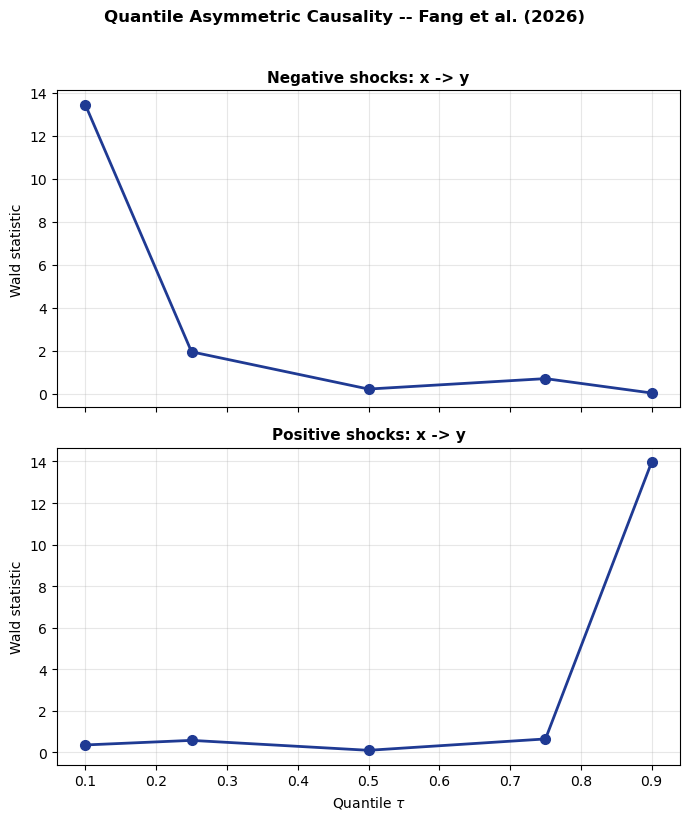

In [11]:
q = asycaus.quantile(y, x, shock='both',
                     quantiles=(0.1, 0.25, 0.5, 0.75, 0.9),
                     max_lag=4, fourier=True, kmax=2, plot=False)
q.table.to_csv(os.path.join(TBL_DIR, '06_quantile.csv'), index=False)
fig = q.plot(save=os.path.join(FIG_DIR, '07_quantile.png'))


## 9. Efficient asymmetric tests — Hatemi-J (2024)

Joint SUR estimation of the positive and negative systems. Four hypotheses
are produced in one shot:

| # | Null |
|---|---|
| 1 | No causality via **positive** shocks |
| 2 | No causality via **negative** shocks |
| 3 | **Joint** no causality (1 AND 2) |
| 4 | **Positive = Negative** causal coefficients ← formal asymmetry test |


       Efficient Asymmetric Causality (SUR)  --  Hatemi-J (2024)        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Null hypothesis             ┃    Wald ┃ df ┃  Asy p ┃ Decision       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ No causality via POS shocks │  0.5543 │  1 │ 0.4565 │ Fail to reject │
│ No causality via NEG shocks │ 12.9621 │  1 │ 0.0003 │ Reject         │
│ Joint no causality          │ 14.3627 │  2 │ 0.0008 │ Reject         │
│ POS = NEG causal effects    │ 10.5752 │  1 │ 0.0011 │ Reject         │
└─────────────────────────────┴─────────┴────┴────────┴────────────────┘

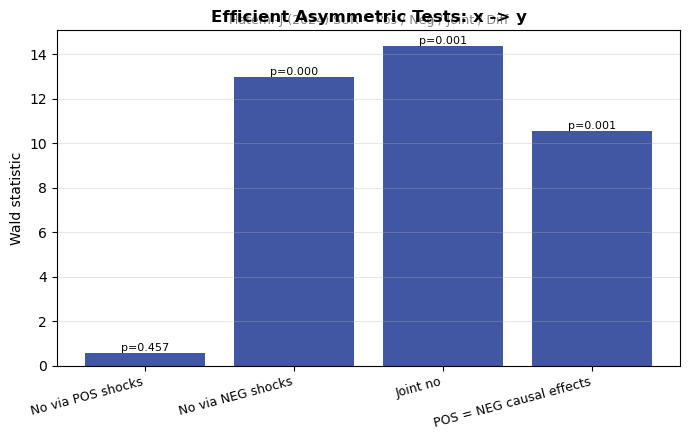

In [12]:
eff = asycaus.efficient(y, x, max_lag=6, plot=False)
eff.table.to_csv(os.path.join(TBL_DIR, '07_efficient.csv'))
fig = eff.plot(save=os.path.join(FIG_DIR, '08_efficient.png'))


## 10. Full battery + unified summary

A single `asycaus.all_tests(...)` call runs everything above and prints one
unified row per (test × shock).


In [13]:
battery = asycaus.all_tests(y, x, max_lag=4, boot=200,
                            skip_dynamic=True, skip_spectral=False,
                            plot=False)
battery.summary.to_csv(os.path.join(TBL_DIR, '08_battery_summary.csv'), index=False)
battery.summary



                         ASYMMETRIC CAUSALITY BATTERY                         
                          Author: Dr Merwan Roudane                           
 Direction tested:  causvar -> depvar

[1/6] Static Asymmetric Causality (Hatemi-J 2012)...



[2/6] Fourier Asymmetric TY (Nazlioglu et al. 2016)...

[3/6] Efficient Asymmetric (Hatemi-J 2024)...

[4/6] Spectral Asymmetric (Bahmani-Oskooee et al. 2016)...

[5/6] Quantile Asymmetric (Fang et al. 2026)...


                       UNIFIED ASYMMETRIC CAUSALITY SUMMARY                        
╔══════════════════════════════╤═══════╤═══════════════╤═════════╤════════════════╗
║ Test                         │ Shock │     Statistic │ p-value │ Decision       ║
╟──────────────────────────────┼───────┼───────────────┼─────────┼────────────────╢
║ Static (Hatemi-J 2012)       │  Pos  │        0.0482 │  0.8261 │ Fail to reject ║
║ Static (Hatemi-J 2012)       │  Neg  │        0.2710 │  0.6027 │ Fail to reject ║
║ Fourier (Nazlioglu 2016)     │  Pos  │      101.5157 │  0.0000 │ Reject         ║
║ Fourier (Nazlioglu 2016)     │  Neg  │      332.3207 │  0.0000 │ Reject         ║
║ Efficient Pos only (HJ 2024) │  Pos  │        0.5543 │  0.4565 │ Fail to reject ║
║ Efficient Neg only (HJ 2024) │  Neg  │       12.9621 │  0.0003 │ Reject         ║
║ Efficient Joint (HJ 2024)    │ both  │       14.3627 │  0.0008 │ Reject         ║
║ Efficient Pos=Neg (HJ 2024)  │ diff  │       10.5752 │  0.0011 │ Reject         ║
║ Spectral (BCRanjbar 2016)    │  Pos  │   0.00% freq. │  0.0000 │ Fail to reject ║
║ Spectral (BCRanjbar 2016)    │  Neg  │   0.00% freq. │  0.0000 │ Fail to reject ║
║ Quantile (Fang et al. 2026)  │  Pos  │  0.00% quant. │  0.0000 │ Fail to reject ║
║ Quantile (Fang et al. 2026)  │  Neg  │ 20.00% quant. │  0.2000 │ Reject at some ║
╚══════════════════════════════╧═══════╧═══════════════╧═════════╧════════════════╝
         Decision at 5% level.  Spectral/quantile rows report fraction of          
                         frequencies/quantiles rejecting.                          

,Test,Shock,Statistic,p-value,Decision
0,Static (Hatemi-J 2012),Pos,0.048244,8.261478e-01,Fail to reject
1,Static (Hatemi-J 2012),Neg,0.271009,6.026560e-01,Fail to reject
2,Fourier (Nazlioglu 2016),Pos,101.515733,7.089810e-24,Reject
3,Fourier (Nazlioglu 2016),Neg,332.320745,3.001451e-74,Reject
4,Efficient Pos only (HJ 2024),Pos,0.55434,4.565498e-01,Fail to reject
5,Efficient Neg only (HJ 2024),Neg,12.962146,3.178526e-04,Reject
6,Efficient Joint (HJ 2024),both,14.362713,7.606353e-04,Reject
7,Efficient Pos=Neg (HJ 2024),diff,10.575201,1.146148e-03,Reject
8,Spectral (BCRanjbar 2016),Pos,0.00% freq.,0.000000e+00,Fail to reject
9,Spectral (BCRanjbar 2016),Neg,0.00% freq.,0.000000e+00,Fail to reject


## 11. Conclusion

The `asycaus` library produces a **clean, end-to-end** asymmetric-causality
analysis on real financial data with one consistent API, professional tables
and publication-quality plots.

Every artifact above is saved under `docs/figures/` and `docs/tables/` for
embedding in the GitHub Pages site.

---

**Citation**

> Roudane, M. (2026). *asycaus: Asymmetric Granger-causality suite for Python*.
> Version 1.0.0. https://github.com/merwanroudane/asycaus

**Companion Stata package on SSC:** `ssc install asycaus`
